**Flipkart E-Commerce Data Analysis**

**1) Business Context**

> The client is Flipkart, one of India's leading e-commerce platform.

>The dataset contains product listings on Flipkart, including product titles, descriptions, ratings, reviews, prices, and other metadata.

>Problem Statement: Flipkart wants to understand the trends in its product listings to make data driven decisions about marketing, pricing, and customer experience.They need insights into product performance, pricing trends, and category-wise behavior.

>Objective: As a data scientist consultant, I will perform exploratory data analysis(EDA) to uncover valuable insights which further helps in decision making process.

**2) Data Collection**

The dataset utilized for this analysis has been retrieved from source kaggle - "https://www.kaggle.com/datasets/atharvjairath/flipkart-ecommerce-dataset/data"

**Business Questions addressed in Exploratory Data Analysis**
1. How do average discount percentages vary across product categories, and what do these patterns reveal about our pricing strategies and competitive positioning within each segment?
2. To what extent do discount levels impact customer satisfaction, as measured by product ratings, and are we potentially devaluing perceived quality by over-discounting in specific categories?
3. What are the top 10 most expensive product categories?
4. How significant is the price difference between listed MRP and discounted selling price across product lines?
5. What are the most common brands listed on Flipkart, and how dominant are they?
6. What is the relationship between product pricing and customer ratings, and does higher pricing correlate with improved customer satisfaction?

Initially, we have to load the dataset and view the structure. Using functions such as shape and head to see the number of columns, rows and a preview of the dataset.

#Importing Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Reading The Dataset

In [ ]:
df_org = pd.read_csv('/content/flipkart_com-ecommerce.csv')

print(df_org.shape)

df_org.head()

(20000, 15)


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


#Data Cleaning

Checking for null values availability.

In [ ]:
df = df_org.copy()
df.isna().sum().sort_values(ascending=False)

,0
brand,5864
discounted_price,78
retail_price,78
product_specifications,14
image,3
description,2
crawl_timestamp,0
pid,0
product_category_tree,0
product_name,0


In [ ]:
df["main_category"] = df["product_category_tree"].str.extract(r'"([^">]+)"')
df["main_category"].value_counts().head(10)

,count
main_category,
Clovia Women's Full Coverage Bra,9
Vishudh Printed Women's Straight Kurta,8
Lilliput Top Baby Girl's Combo,8
Olvin Aviator Sunglasses,7
Clovia Women's T-Shirt Bra,6
MASARA Solid Women's Straight Kurta,5
Sunglasses,5
Dressberry Gold Synthetic Clutch,4
"Firangi Cotton, Polyester Free Floor Mat Firangi...",4


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
main_category,19658
brand,5864
retail_price,78
discounted_price,78
product_specifications,14
image,3
description,2
uniq_id,0
product_category_tree,0
pid,0


In [ ]:
df["discount_percent"] = ((df["retail_price"] - df["discounted_price"]) / df["retail_price"]) * 100
df["discount_percent"] = df["discount_percent"].clip(lower=0)
df['uniq_id'] = df['uniq_id'].fillna('unknown_id')
df['brand'] = df['brand'].fillna('Unknown').astype(str).str.strip()

df = df.dropna(subset=["product_name", "retail_price", "discounted_price", "main_category"])

df.isnull().sum()

,0
uniq_id,0
crawl_timestamp,0
product_url,0
product_name,0
product_category_tree,0
pid,0
retail_price,0
discounted_price,0
image,0
is_FK_Advantage_product,0


In [ ]:
df.duplicated().values.any()

np.False_

>Observations:
* We have cleaned the dataset column by column.
* Parsed the "product_category_tree" to extract "main_category".
* No duplicates are available.

**3) Exploratory Data Analysis**

#Correlation Analysis

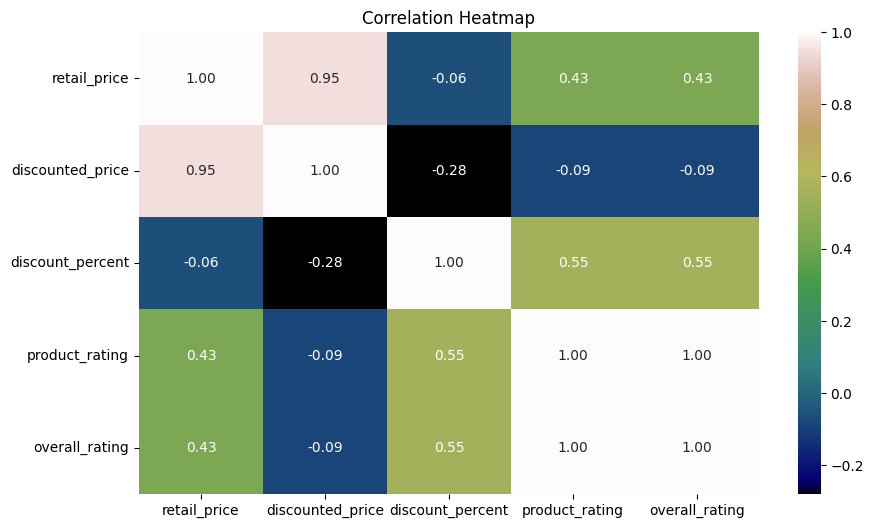

In [ ]:
df["product_rating"] = pd.to_numeric(df["product_rating"], errors="coerce")
df["overall_rating"] = pd.to_numeric(df["overall_rating"], errors="coerce")
plt.figure(figsize=(10, 6))
corr = df[["retail_price", "discounted_price", "discount_percent", "product_rating", "overall_rating"]].corr()
sns.heatmap(corr, annot=True, cmap="gist_earth", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Result**:  
- *Product_rating* and *overall_rating* show a moderate positive correlation with *retail_price* (0.43) and *discounted_price* (0.09 to 0.55), indicating a tendency to increase with higher prices.
- *Discount_percent* has a moderate positive correlation with *product_rating* (0.55) and *overall_rating* (0.55), suggesting that higher discounts might be associated with higher ratings.
- *Retail_price* and *discounted_price* have a strong positive correlation (0.95), meaning they tend to increase together.
- *Discount_percent* has a moderate negative correlation with both *retail_price* (-0.06) and *discounted_price* (-0.28), indicating a weak to moderate inverse relationship.


# 4) **Business Questions**

**1. How do average discount percentages vary across product categories, and what do these patterns reveal about our pricing strategies and competitive positioning within each segment?**

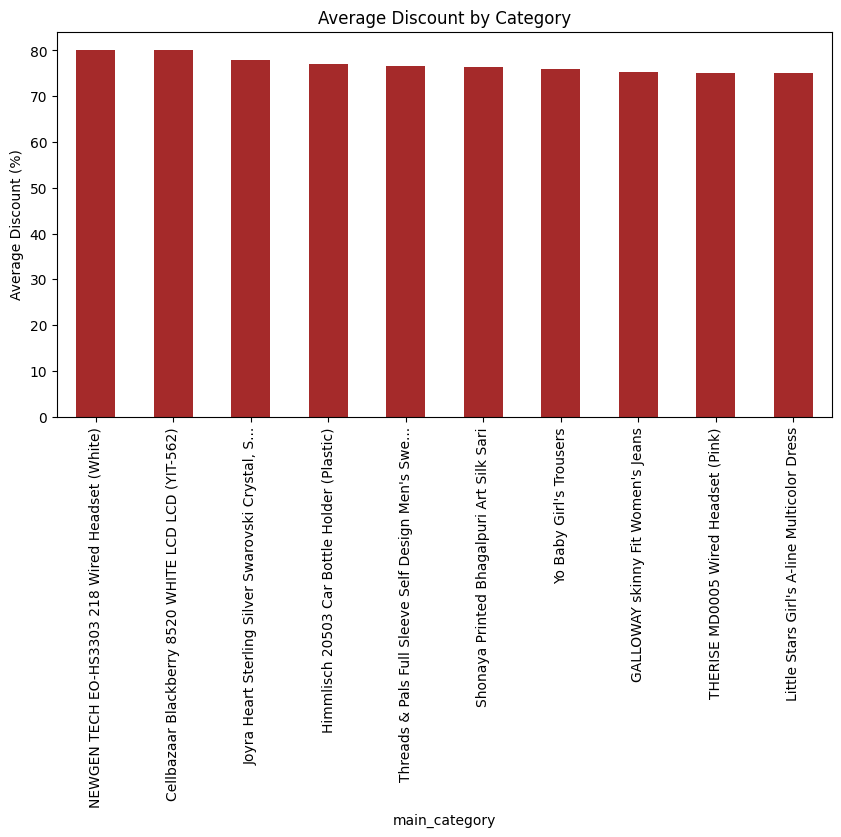

In [ ]:
avg_discount = df.groupby("main_category")["discount_percent"].mean().sort_values(ascending=False).head(10)
avg_discount.plot(kind="bar", color="brown", figsize=(10, 5), title="Average Discount by Category")
plt.ylabel("Average Discount (%)")
plt.show()

* The average discount percentages across these categories are consistently high (around 80%), revealing an aggressive pricing strategy focused on steep markdowns to drive sales, clear inventory, or compete in price-sensitive segments.
* This positions Flipkart as a bargain-friendly platform but also signals potential risks of margin erosion and overreliance on discounts.

**2. To what extent do discount levels impact customer satisfaction, as measured by product ratings, and are we potentially devaluing perceived quality by over-discounting in specific categories?**

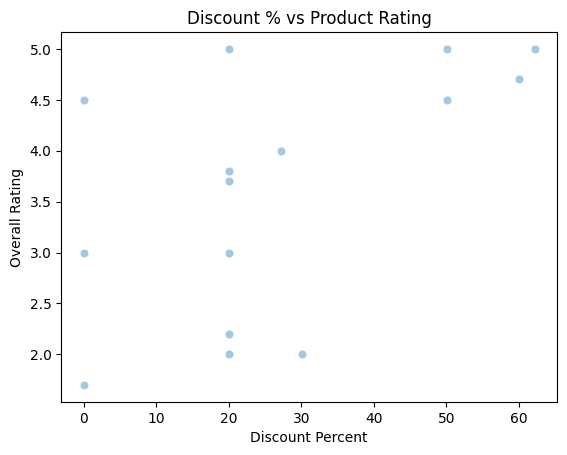

,discount_percent,overall_rating
discount_percent,1.000000,0.550497
overall_rating,0.550497,1.000000


In [ ]:
sns.scatterplot(data=df, x="discount_percent", y="overall_rating", alpha=0.4)
plt.title("Discount % vs Product Rating")
plt.xlabel("Discount Percent")
plt.ylabel("Overall Rating")
plt.show()

df[["discount_percent", "overall_rating"]].corr()

>Based on the scatter plot and the correlation (+0.55), there’s moderate evidence that higher discounts are associated with higher product ratings, suggesting discounts currently support — rather than erode — customer satisfaction.

**3. What are the top 10 most expensive product categories?**

/tmp/ipython-input-12-3954538386.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=expensive_cats.values, y=expensive_cats.index, palette='magma')


Text(0.5, 1.0, 'Top 10 Expensive Categories (Avg Price)')

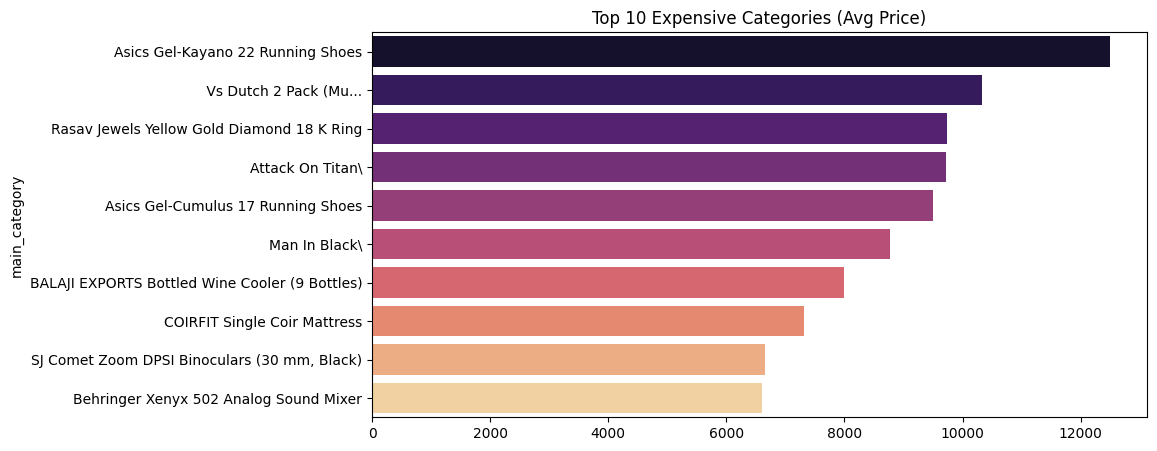

In [ ]:
expensive_cats = df.groupby('main_category')['discounted_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=expensive_cats.values, y=expensive_cats.index, palette='magma')
plt.title('Top 10 Expensive Categories (Avg Price)')

* Running Shoes, Jewelry, and Specialty Products like Wine Coolers or Sound Mixers are among the most expensive.

* This indicates potential premium segments Flipkart could target for upselling, brand collaborations, or curated recommendations.

**4. How significant is the price difference between listed MRP and discounted selling price across product lines??**

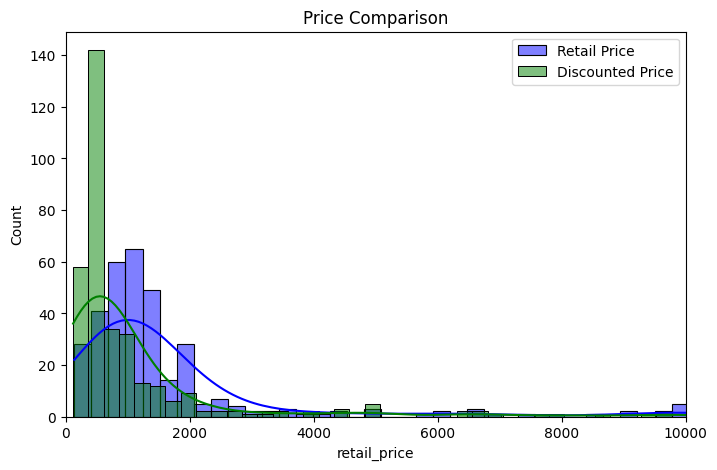

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["retail_price"], label="Retail Price", color="blue", kde=True, bins=50)
sns.histplot(df["discounted_price"], label="Discounted Price", color="green", kde=True, bins=50)
plt.legend()
plt.title("Price Comparison")
plt.xlim(0, 10000)
plt.show()

* Most discounted products are priced under ₹1000, even when their MRPs range from ₹500 to ₹2000.
* Both price distributions are right-skewed, meaning while most items are inexpensive, a small portion of high-value products raises the overall average.

**5. What are the most common brands listed on Flipkart, and how dominant are they?**

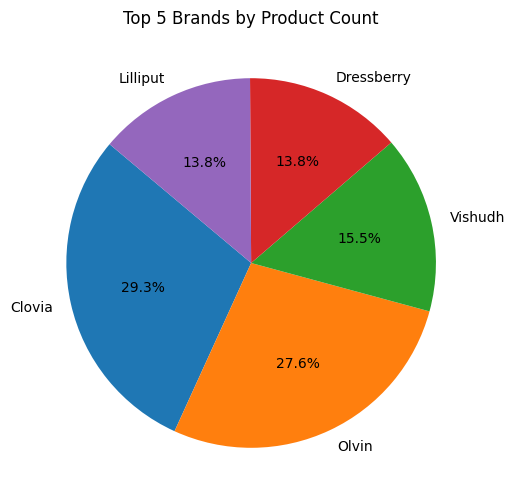

In [ ]:
top_brands = df["brand"].value_counts().head(5)
top_brands.plot(kind="pie", autopct="%1.1f%%", startangle=140, figsize=(6, 6))
plt.title("Top 5 Brands by Product Count")
plt.ylabel("")
plt.show()

Over 56% of listings from the top 5 brands come from just Clovia and Olvin, suggesting these two brands are major suppliers or partners on Flipkart.

**6. What is the relationship between product pricing and customer ratings, and does higher pricing correlate with improved customer satisfaction?**

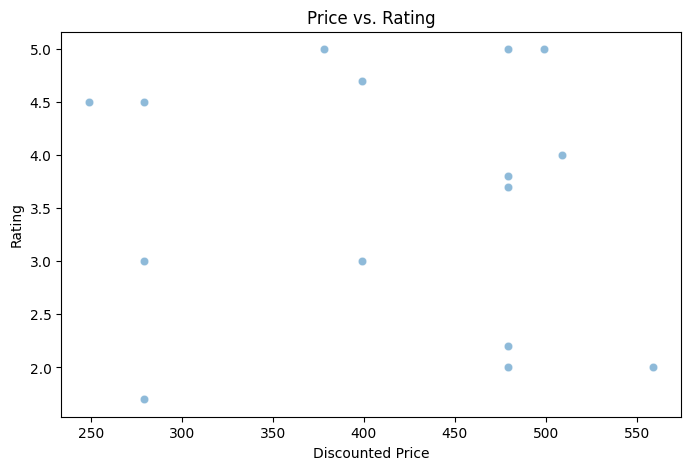

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discounted_price', y='overall_rating', data=df, alpha=0.5)
plt.title('Price vs. Rating')
plt.xlabel('Discounted Price')
plt.ylabel('Rating')
plt.show()

* The data shows a wide dispersion of ratings across all price points, with no clear upward trend as prices increase.
* Both low-priced and high-priced products exhibit a broad range of ratings, from around 3.0 to 4.5.
*This suggests that higher prices do not consistently result in better customer ratings.

# 5)**Conclusion**

## **Summary of findings:**
-  A few main product categories dominate the listings — showing Flipkart's catalog is highly skewed toward popular segments.  


-   Most products have moderately high ratings, suggesting general customer satisfaction, but with some outliers indicating quality or expectation gaps.  

  
-   There is limited correlation between product price and rating, indicating that higher price does not automatically guarantee better customer reviews.  


-   Products with more reviews often maintain moderate to high ratings, implying that popular products tend to satisfy buyers reasonably well.
-  Price ranges vary significantly across categories — some categories are clearly premium, while others cater to budget-conscious shoppers.

## **Strengths**

* Cleaned and standardized messy price and category data for meaningful insights.
- Covered multiple aspects: product mix, pricing, ratings, reviews.
- Applied diverse Python/Pandas techniques: cleaning, grouping, visualizations, and correlation.
- Highlighted actionable patterns in how products are rated and reviewed.

##**Recommendations**:
1. Focus on improving visibility of top-rated but lower-priced products.
2. Create campaigns around high-rated categories.
3. Analyze user behavior further by integrating click or sales data.
4. Use rating and review trends to manage inventory and pricing strategies.
5. Reevaluate discounts in low-performing categories. Continue to track price sensitivity and rating trends over time.
